In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/5week/diabetes.csv")
df.head
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [2]:
#결측값 처리
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[zero_cols] = df[zero_cols].replace(0, pd.NA)
df[zero_cols] = df[zero_cols].fillna(df[zero_cols].median())

/tmp/ipykernel_486/748905432.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[zero_cols] = df[zero_cols].fillna(df[zero_cols].median())


In [4]:
#파생 피처 추가
df['Glucose_Insulin'] = df['Glucose'] * df['Insulin']  # 인슐린 저항성
df['SkinThickness_BP'] = df['SkinThickness'] * df['BloodPressure']

selected_features = [
    'SkinThickness', 'BloodPressure', 'Glucose', 'Insulin',
    'DiabetesPedigreeFunction', 'Age', 'Pregnancies',
    'Glucose_Insulin', 'SkinThickness_BP'
]
# Input(shape=(9,))
X = df[selected_features].values
X

array([[3.5000e+01, 7.2000e+01, 1.4800e+02, ..., 6.0000e+00, 1.8500e+04,
        2.5200e+03],
       [2.9000e+01, 6.6000e+01, 8.5000e+01, ..., 1.0000e+00, 1.0625e+04,
        1.9140e+03],
       [2.9000e+01, 6.4000e+01, 1.8300e+02, ..., 8.0000e+00, 2.2875e+04,
        1.8560e+03],
       ...,
       [2.3000e+01, 7.2000e+01, 1.2100e+02, ..., 5.0000e+00, 1.3552e+04,
        1.6560e+03],
       [2.9000e+01, 6.0000e+01, 1.2600e+02, ..., 1.0000e+00, 1.5750e+04,
        1.7400e+03],
       [3.1000e+01, 7.0000e+01, 9.3000e+01, ..., 1.0000e+00, 1.1625e+04,
        2.1700e+03]])

In [5]:
y = df['BMI']
y.head()

,BMI
0,33.6
1,26.6
2,23.3
3,28.1
4,43.1


In [6]:
from sklearn.model_selection import train_test_split

X_train,X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape,

((614, 9), (614,), (154, 9), (154,))

In [7]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(X_train)
X_test  = scaler_X.transform(X_test)

y_train = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test  = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

In [8]:
from keras.models import Sequential
from keras.optimizers import SGD,Adam
from keras.layers import Dense, Input, Dropout

model = Sequential()

model = Sequential([
    Input(shape=(9,)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1)
])

model.compile(optimizer = 'adam', loss = 'mse', metrics = ['mse'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,865 (19.00 KB)

 Trainable params: 4,865 (19.00 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
N_EPOCHS = 100

history=model.fit(x=X_train, y=y_train, epochs=N_EPOCHS, batch_size=32,validation_data= (X_test,y_test))
y_pred = model.predict(X_test)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.9025 - mse: 0.9025 - val_loss: 0.7080 - val_mse: 0.7080
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7031 - mse: 0.7031 - val_loss: 0.7518 - val_mse: 0.7518
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6586 - mse: 0.6586 - val_loss: 0.7430 - val_mse: 0.7430
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6159 - mse: 0.6159 - val_loss: 0.7506 - val_mse: 0.7506
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6181 - mse: 0.6181 - val_loss: 0.7315 - val_mse: 0.7315
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6366 - mse: 0.6366 - val_loss: 0.7414 - val_mse: 0.7414
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6149 - mse: 0.6149 - val_loss: 0.7291 - val_mse: 0.7291
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6442 - mse: 0.6442 - val_loss: 0.7266 - val_mse: 0.7266
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.60

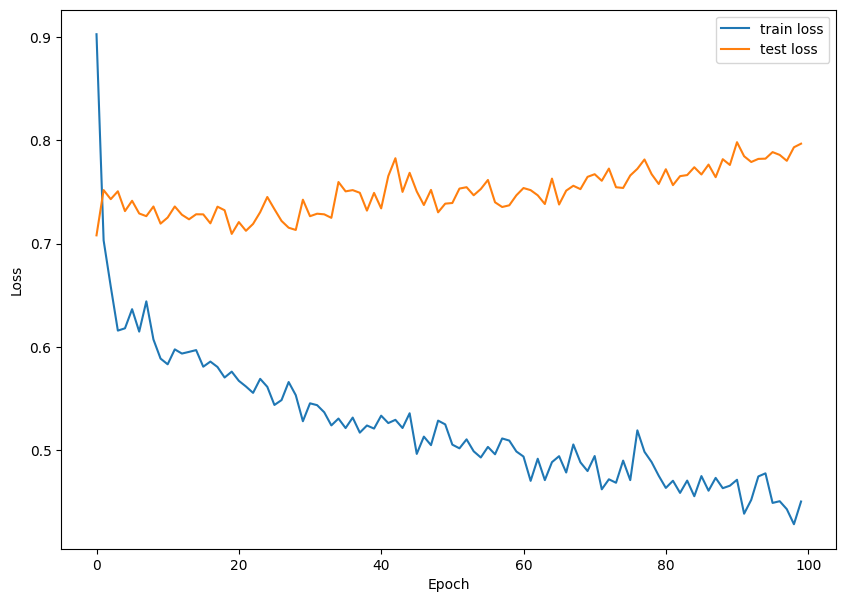

In [10]:
# loss 그래프
import matplotlib.pyplot as plt
plt.figure(figsize=(10,7))
plt.plot(range(N_EPOCHS), history.history['loss'], label='train loss')
plt.plot(range(N_EPOCHS), history.history['val_loss'], label='test loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [12]:
y_pred_s = y_pred.flatten()
y_pred_orig = scaler_y.inverse_transform(y_pred_s.reshape(-1, 1)).ravel()
y_test_orig = scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel()

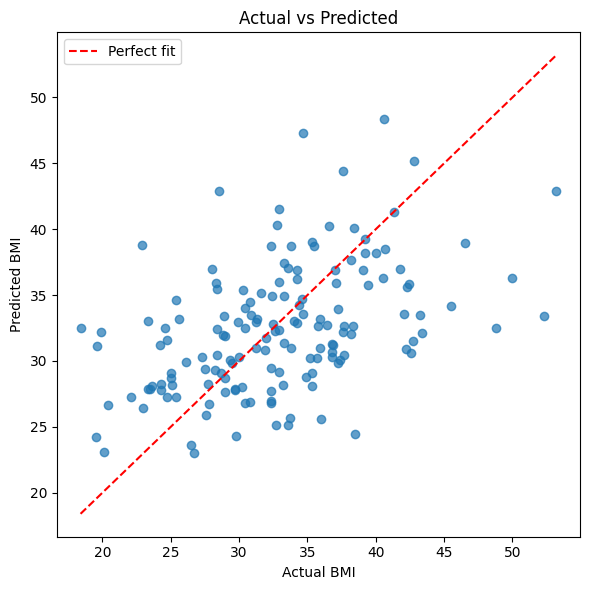

In [13]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_orig, y_pred_orig, alpha=0.7)
plt.plot([y_test_orig.min(), y_test_orig.max()],
         [y_test_orig.min(), y_test_orig.max()],
         'r--', label='Perfect fit')
plt.xlabel('Actual BMI')
plt.ylabel('Predicted BMI')
plt.title('Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()